In [50]:
import pandas as pd
import numpy as np

import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

from gnews import GNews

from transformers import AutoTokenizer,AutoModelForSequenceClassification,pipeline,DistilBertTokenizer

In [2]:
'''gn = GNews(language='en', country='US', max_results=5)

# Top news
top = gn.get_top_news()

# Search by keyword
results = gn.get_news('artificial intelligence')

# By topic
tech_news = gn.get_news_by_topic('TECHNOLOGY')

# By location
india_news = gn.get_news_by_location('India')

# Full article
article = gn.get_full_article(results[0]['url'])
print(article.text))'''

"gn = GNews(language='en', country='US', max_results=5)\n\n# Top news\ntop = gn.get_top_news()\n\n# Search by keyword\nresults = gn.get_news('artificial intelligence')\n\n# By topic\ntech_news = gn.get_news_by_topic('TECHNOLOGY')\n\n# By location\nindia_news = gn.get_news_by_location('India')\n\n# Full article\narticle = gn.get_full_article(results[0]['url'])\nprint(article.text))"

In [42]:
def acquire_news_keyword(topic:str,results:int):
    gn=GNews(language='en', max_results=results)
    return gn.get_news(topic)

def acquire_news_top(results:int):
    gn=GNews(language='en', max_results=results)
    return gn.get_top_news()

def acquire_news_topic(topic:str,results:int):
    gn=GNews(language='en', max_results=results)
    return gn.get_news(topic)

def filter_new_news(new_news:pd.DataFrame,old_news:pd.DataFrame):
    x=0
    for index,title in enumerate(new_news.iloc[:,0]):
        if title in old_news.iloc[:,0].values:
            new_news.drop(index=index,axis=1,inplace=True)
            x=x+1
        else:
            pass
    print('Total news dropped:',x)

def record_news(new_news:pd.DataFrame,header:bool = False):
    new_news.to_csv(r"C:\Users\Asus\Documents\Skills\Python\Sentiment Analysis\sentiment_gnews\msftn_news.csv",header=header,index=False,mode='a')

def acquire_sentiment(new_news:pd.DataFrame):
    model_ckpt = "ProsusAI/finbert"
    classifier = pipeline('text-classification', model=model_ckpt)

    _ = [classifier(text, return_all_scores=True) for text in new_news.iloc[:, 1]]
    new_news['label'] = [res[0]['label'] for res in _]
    new_news['score'] = [res[0]['score'] for res in _]
    _.clear()


In [32]:
msftn_df=pd.DataFrame(acquire_news_keyword(topic='Microsoft',results=100))
topn_df=pd.DataFrame(acquire_news_top(results=100))
fin_df=pd.DataFrame(acquire_news_topic(topic='Finance',results=100))

"topn_df=pd.DataFrame(acquire_news_top(results=100))\nfin_df=pd.DataFrame(acquire_news_topic(topic='Finance',results=100))"

In [34]:
msftn_df.head()

,title,description,published date,url,publisher
0,Microsoft: Stock to Avoid or Once-in-a-Decade ...,Microsoft: Stock to Avoid or Once-in-a-Decade ...,"Mon, 23 Mar 2026 13:45:00 GMT",https://news.google.com/rss/articles/CBMilwFBV...,"{'href': 'https://www.fool.com', 'title': 'The..."
1,Microsoft named a Leader in The Forrester Wave...,Microsoft named a Leader in The Forrester Wave...,"Mon, 23 Mar 2026 15:30:10 GMT",https://news.google.com/rss/articles/CBMi8AFBV...,"{'href': 'https://www.microsoft.com', 'title':..."
2,Microsoft outs Windows 11 KB5085516 to fix int...,Microsoft outs Windows 11 KB5085516 to fix int...,"Mon, 23 Mar 2026 18:18:24 GMT",https://news.google.com/rss/articles/CBMiugFBV...,"{'href': 'https://www.neowin.net', 'title': 'N..."
3,Microsoft releases emergency fix for account i...,Microsoft releases emergency fix for account i...,"Mon, 23 Mar 2026 11:24:00 GMT",https://news.google.com/rss/articles/CBMickFVX...,"{'href': 'https://www.theregister.com', 'title..."
4,Microsoft: Beneath The Selloff (NASDAQ:MSFT) -...,Microsoft: Beneath The Selloff (NASDAQ:MSFT) ...,"Mon, 23 Mar 2026 14:59:25 GMT",https://news.google.com/rss/articles/CBMidEFVX...,"{'href': 'https://seekingalpha.com', 'title': ..."


In [35]:
msftn_df.shape

(100, 5)

In [18]:
topn_df.head()

,title,description,published date,url,publisher
0,Live Updates: Trump says ultimatum for Iran to...,Live Updates: Trump says ultimatum for Iran to...,"Mon, 23 Mar 2026 19:10:00 GMT",https://news.google.com/rss/articles/CBMikwFBV...,"{'href': 'https://www.cbsnews.com', 'title': '..."
1,ICE officers go to TSA checkpoints at Trump's ...,ICE officers go to TSA checkpoints at Trump's ...,"Mon, 23 Mar 2026 19:09:00 GMT",https://news.google.com/rss/articles/CBMiqgFBV...,"{'href': 'https://apnews.com', 'title': 'AP Ne..."
2,US Supreme Court conservatives lean toward Rep...,US Supreme Court conservatives lean toward Rep...,"Mon, 23 Mar 2026 10:02:25 GMT",https://news.google.com/rss/articles/CBMisgFBV...,"{'href': 'https://www.reuters.com', 'title': '..."
3,Trump rejects off-ramp to fund DHS as airport ...,Trump rejects off-ramp to fund DHS as airport ...,"Mon, 23 Mar 2026 17:36:19 GMT",https://news.google.com/rss/articles/CBMiuAFBV...,"{'href': 'https://www.nbcnews.com', 'title': '..."
4,Two boys made deepfake porn of 60 girls. It le...,Two boys made deepfake porn of 60 girls. It le...,"Mon, 23 Mar 2026 17:40:46 GMT",https://news.google.com/rss/articles/CBMiyAFBV...,"{'href': 'https://www.usatoday.com', 'title': ..."


In [19]:
fin_df.head()

,title,description,published date,url,publisher
0,Dow jumps 800 points after Trump says U.S. and...,Dow jumps 800 points after Trump says U.S. and...,"Mon, 23 Mar 2026 19:30:00 GMT",https://news.google.com/rss/articles/CBMid0FVX...,"{'href': 'https://www.cnbc.com', 'title': 'CNBC'}"
1,Gold (XAUUSD) & Silver Price Forecast: 6% Gold...,Gold (XAUUSD) & Silver Price Forecast: 6% Gold...,"Mon, 23 Mar 2026 08:48:00 GMT",https://news.google.com/rss/articles/CBMivAFBV...,"{'href': 'https://www.fxempire.com', 'title': ..."
2,3 Vanguard ETFs to Buy With $100 and Hold Fore...,3 Vanguard ETFs to Buy With $100 and Hold Fore...,"Mon, 23 Mar 2026 14:15:00 GMT",https://news.google.com/rss/articles/CBMilgFBV...,"{'href': 'https://www.fool.com', 'title': 'The..."
3,"Bitcoin price news: BTC surges 5% to $71,000 a...","Bitcoin price news: BTC surges 5% to $71,000 a...","Mon, 23 Mar 2026 15:38:18 GMT",https://news.google.com/rss/articles/CBMivAFBV...,"{'href': 'https://www.coindesk.com', 'title': ..."
4,Stocks making the biggest moves midday: Palant...,Stocks making the biggest moves midday: Palant...,"Mon, 23 Mar 2026 17:05:12 GMT",https://news.google.com/rss/articles/CBMimwFBV...,"{'href': 'https://www.cnbc.com', 'title': 'CNBC'}"


In [3]:
path=r"C:\Users\Asus\Documents\Skills\Python\Sentiment Analysis\sentiment_gnews\msftn_news.csv"
news_df=pd.read_csv(path)

In [4]:
news_df.head()

,title,description,published date,url,publisher
0,Microsoft: Stock to Avoid or Once-in-a-Decade ...,Microsoft: Stock to Avoid or Once-in-a-Decade ...,"Mon, 23 Mar 2026 13:45:00 GMT",https://news.google.com/rss/articles/CBMilwFBV...,"{'href': 'https://www.fool.com', 'title': 'The..."
1,Microsoft named a Leader in The Forrester Wave...,Microsoft named a Leader in The Forrester Wave...,"Mon, 23 Mar 2026 15:30:10 GMT",https://news.google.com/rss/articles/CBMi8AFBV...,"{'href': 'https://www.microsoft.com', 'title':..."
2,Microsoft outs Windows 11 KB5085516 to fix int...,Microsoft outs Windows 11 KB5085516 to fix int...,"Mon, 23 Mar 2026 18:18:24 GMT",https://news.google.com/rss/articles/CBMiugFBV...,"{'href': 'https://www.neowin.net', 'title': 'N..."
3,Microsoft releases emergency fix for account i...,Microsoft releases emergency fix for account i...,"Mon, 23 Mar 2026 11:24:00 GMT",https://news.google.com/rss/articles/CBMickFVX...,"{'href': 'https://www.theregister.com', 'title..."
4,Microsoft: Beneath The Selloff (NASDAQ:MSFT) -...,Microsoft: Beneath The Selloff (NASDAQ:MSFT) ...,"Mon, 23 Mar 2026 14:59:25 GMT",https://news.google.com/rss/articles/CBMidEFVX...,"{'href': 'https://seekingalpha.com', 'title': ..."


In [5]:
news_df.shape

(176, 5)

In [6]:
ndf=pd.DataFrame(acquire_news_keyword(topic='Microsoft',results=100))

In [7]:
ndf.head()

,title,description,published date,url,publisher
0,Less AI? Microsoft Pledges to Focus on Windows...,Less AI? Microsoft Pledges to Focus on Windows...,"Sun, 22 Mar 2026 21:50:17 GMT",https://news.google.com/rss/articles/CBMiowFBV...,"{'href': 'https://www.pcmag.com', 'title': 'PC..."
1,Melius analyst: Microsoft’s Copilot reorganiza...,Melius analyst: Microsoft’s Copilot reorganiza...,"Mon, 23 Mar 2026 22:56:52 GMT",https://news.google.com/rss/articles/CBMiqgFBV...,"{'href': 'https://247wallst.com', 'title': '24..."
2,TD SYNNEX Achieves Microsoft’s Newly Establish...,TD SYNNEX Achieves Microsoft’s Newly Establish...,"Tue, 24 Mar 2026 13:00:00 GMT",https://news.google.com/rss/articles/CBMiiwFBV...,"{'href': 'https://au.finance.yahoo.com', 'titl..."
3,OpenAI calls out Microsoft reliance as risk in...,OpenAI calls out Microsoft reliance as risk in...,"Mon, 23 Mar 2026 23:00:28 GMT",https://news.google.com/rss/articles/CBMipAFBV...,"{'href': 'https://www.cnbc.com', 'title': 'CNBC'}"
4,OpenAI lists Microsoft reliance as a risk in p...,OpenAI lists Microsoft reliance as a risk in p...,"Tue, 24 Mar 2026 04:11:15 GMT",https://news.google.com/rss/articles/CBMivwFBV...,"{'href': 'https://www.investing.com', 'title':..."


In [8]:
ndf.shape

(100, 5)

In [9]:
filter_new_news(new_news=ndf,old_news=news_df)

Total news dropped: 96


In [10]:
ndf.shape

(4, 5)

In [11]:
ndf.head()

,title,description,published date,url,publisher
2,TD SYNNEX Achieves Microsoft’s Newly Establish...,TD SYNNEX Achieves Microsoft’s Newly Establish...,"Tue, 24 Mar 2026 13:00:00 GMT",https://news.google.com/rss/articles/CBMiiwFBV...,"{'href': 'https://au.finance.yahoo.com', 'titl..."
22,Microsoft Is Removing 'Unnecessary' Copilot Fe...,Microsoft Is Removing 'Unnecessary' Copilot Fe...,"Tue, 24 Mar 2026 02:58:40 GMT",https://news.google.com/rss/articles/CBMihAFBV...,"{'href': 'https://lifehacker.com', 'title': 'L..."
41,Microsoft rolls back some of its Copilot AI bl...,Microsoft rolls back some of its Copilot AI bl...,"Fri, 20 Mar 2026 20:53:09 GMT",https://news.google.com/rss/articles/CBMimwFBV...,"{'href': 'https://techcrunch.com', 'title': 't..."
99,Microsoft at NVIDIA GTC: New solutions for Mic...,Microsoft at NVIDIA GTC: New solutions for Mic...,"Mon, 16 Mar 2026 20:38:27 GMT",https://news.google.com/rss/articles/CBMi3AFBV...,"{'href': 'https://blogs.microsoft.com', 'title..."


In [13]:
record_news(ndf,header=False)

In [14]:
del news_df

In [45]:
news_df=pd.read_csv(path)

In [46]:
acquire_sentiment(news_df)

03/24/2026 07:22:23 PM - HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/refs%2Fpr%2F29/model.safetensors "HTTP/1.1 302 Found"


In [47]:
news_df.head()

,title,description,published date,url,publisher,label,score
0,Microsoft: Stock to Avoid or Once-in-a-Decade ...,Microsoft: Stock to Avoid or Once-in-a-Decade ...,"Mon, 23 Mar 2026 13:45:00 GMT",https://news.google.com/rss/articles/CBMilwFBV...,"{'href': 'https://www.fool.com', 'title': 'The...",neutral,0.855668
1,Microsoft named a Leader in The Forrester Wave...,Microsoft named a Leader in The Forrester Wave...,"Mon, 23 Mar 2026 15:30:10 GMT",https://news.google.com/rss/articles/CBMi8AFBV...,"{'href': 'https://www.microsoft.com', 'title':...",neutral,0.604526
2,Microsoft outs Windows 11 KB5085516 to fix int...,Microsoft outs Windows 11 KB5085516 to fix int...,"Mon, 23 Mar 2026 18:18:24 GMT",https://news.google.com/rss/articles/CBMiugFBV...,"{'href': 'https://www.neowin.net', 'title': 'N...",neutral,0.619558
3,Microsoft releases emergency fix for account i...,Microsoft releases emergency fix for account i...,"Mon, 23 Mar 2026 11:24:00 GMT",https://news.google.com/rss/articles/CBMickFVX...,"{'href': 'https://www.theregister.com', 'title...",negative,0.784126
4,Microsoft: Beneath The Selloff (NASDAQ:MSFT) -...,Microsoft: Beneath The Selloff (NASDAQ:MSFT) ...,"Mon, 23 Mar 2026 14:59:25 GMT",https://news.google.com/rss/articles/CBMidEFVX...,"{'href': 'https://seekingalpha.com', 'title': ...",neutral,0.912184


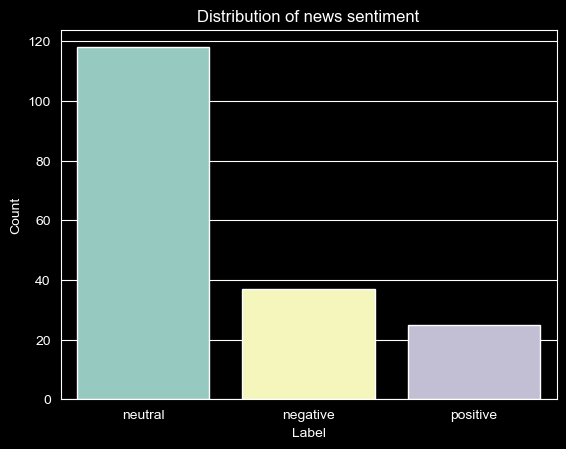

In [52]:
sns.countplot(data=news_df,x="label",hue="label")
plt.title('Distribution of news sentiment')
plt.ylabel('Count')
plt.xlabel('Label')
plt.show()

In [53]:
news_df['published date'].head()

0    Mon, 23 Mar 2026 13:45:00 GMT
1    Mon, 23 Mar 2026 15:30:10 GMT
2    Mon, 23 Mar 2026 18:18:24 GMT
3    Mon, 23 Mar 2026 11:24:00 GMT
4    Mon, 23 Mar 2026 14:59:25 GMT
Name: published date, dtype: object

In [64]:
news_df.index=pd.to_datetime(news_df['published date'])

In [65]:
news_df.head()

,title,description,published date,url,publisher,label,score
published date,,,,,,,
2026-03-23 13:45:00,Microsoft: Stock to Avoid or Once-in-a-Decade ...,Microsoft: Stock to Avoid or Once-in-a-Decade ...,"Mon, 23 Mar 2026 13:45:00 GMT",https://news.google.com/rss/articles/CBMilwFBV...,"{'href': 'https://www.fool.com', 'title': 'The...",neutral,0.855668
2026-03-23 15:30:10,Microsoft named a Leader in The Forrester Wave...,Microsoft named a Leader in The Forrester Wave...,"Mon, 23 Mar 2026 15:30:10 GMT",https://news.google.com/rss/articles/CBMi8AFBV...,"{'href': 'https://www.microsoft.com', 'title':...",neutral,0.604526
2026-03-23 18:18:24,Microsoft outs Windows 11 KB5085516 to fix int...,Microsoft outs Windows 11 KB5085516 to fix int...,"Mon, 23 Mar 2026 18:18:24 GMT",https://news.google.com/rss/articles/CBMiugFBV...,"{'href': 'https://www.neowin.net', 'title': 'N...",neutral,0.619558
2026-03-23 11:24:00,Microsoft releases emergency fix for account i...,Microsoft releases emergency fix for account i...,"Mon, 23 Mar 2026 11:24:00 GMT",https://news.google.com/rss/articles/CBMickFVX...,"{'href': 'https://www.theregister.com', 'title...",negative,0.784126
2026-03-23 14:59:25,Microsoft: Beneath The Selloff (NASDAQ:MSFT) -...,Microsoft: Beneath The Selloff (NASDAQ:MSFT) ...,"Mon, 23 Mar 2026 14:59:25 GMT",https://news.google.com/rss/articles/CBMidEFVX...,"{'href': 'https://seekingalpha.com', 'title': ...",neutral,0.912184


In [66]:
news_df.sort_index()

,title,description,published date,url,publisher,label,score
published date,,,,,,,
2026-03-09 07:00:00,Introducing the First Frontier Suite built on ...,Introducing the First Frontier Suite built on ...,"Mon, 09 Mar 2026 07:00:00 GMT",https://news.google.com/rss/articles/CBMirgFBV...,"{'href': 'https://blogs.microsoft.com', 'title...",neutral,0.844926
2026-03-09 07:00:00,Copilot Cowork: A new way of getting work done...,Copilot Cowork: A new way of getting work done...,"Mon, 09 Mar 2026 07:00:00 GMT",https://news.google.com/rss/articles/CBMirAFBV...,"{'href': 'https://www.microsoft.com', 'title':...",neutral,0.835073
2026-03-16 20:38:27,Microsoft at NVIDIA GTC: New solutions for Mic...,Microsoft at NVIDIA GTC: New solutions for Mic...,"Mon, 16 Mar 2026 20:38:27 GMT",https://news.google.com/rss/articles/CBMi3AFBV...,"{'href': 'https://blogs.microsoft.com', 'title...",neutral,0.883618
2026-03-17 15:11:13,Announcing Copilot leadership update - The Off...,Announcing Copilot leadership update The Offi...,"Tue, 17 Mar 2026 15:11:13 GMT",https://news.google.com/rss/articles/CBMiiAFBV...,"{'href': 'https://blogs.microsoft.com', 'title...",neutral,0.942157
2026-03-20 16:00:00,Secure agentic AI end-to-end - Microsoft,Secure agentic AI end-to-end Microsoft,"Fri, 20 Mar 2026 16:00:00 GMT",https://news.google.com/rss/articles/CBMijwFBV...,"{'href': 'https://www.microsoft.com', 'title':...",neutral,0.946379
...,...,...,...,...,...,...,...
2026-03-24 13:00:00,Huntress Surpasses 10 Million Microsoft 365 Id...,Huntress Surpasses 10 Million Microsoft 365 Id...,"Tue, 24 Mar 2026 13:00:00 GMT",https://news.google.com/rss/articles/CBMiigJBV...,"{'href': 'https://www.globenewswire.com', 'tit...",positive,0.905605
2026-03-24 13:00:00,TD SYNNEX Achieves Microsoft’s Newly Establish...,TD SYNNEX Achieves Microsoft’s Newly Establish...,"Tue, 24 Mar 2026 13:00:00 GMT",https://news.google.com/rss/articles/CBMiiwFBV...,"{'href': 'https://au.finance.yahoo.com', 'titl...",positive,0.854410
2026-03-24 13:00:00,TD SYNNEX Achieves Microsoft’s Newly Establish...,TD SYNNEX Achieves Microsoft’s Newly Establish...,"Tue, 24 Mar 2026 13:00:00 GMT",https://news.google.com/rss/articles/CBMi0wFBV...,"{'href': 'https://www.businesswire.com', 'titl...",positive,0.840248


In [69]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=news_df.index,y=news_df['score'],mode='markers'))
fig.show()